In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual theme
sns.set_theme(style="whitegrid")

# Load the SaaS Sales dataset
df = pd.read_csv('/kaggle/input/datasets/gyaanluthria/saas-sales/SaaS_Sales_Finance_Data.csv')

print("--- DATA STRUCTURE ---")
df.info()

print("\n--- STATISTICAL SUMMARY ---")
display(df.describe())

print("\n--- CATEGORY COUNTS (Top Subscription Tiers) ---")
print(df['Subscription_Tier'].value_counts())

--- DATA STRUCTURE ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Contract_ID                10000 non-null  int64  
 1   Close_Date                 10000 non-null  object 
 2   Sales_Region               10000 non-null  object 
 3   Subscription_Tier          10000 non-null  object 
 4   Acquisition_Channel        10000 non-null  object 
 5   Churn_Risk                 10000 non-null  object 
 6   Monthly_Recurring_Rev      10000 non-null  int64  
 7   Customer_Acquisition_Cost  10000 non-null  int64  
 8   Expected_Lifespan_Months   10000 non-null  int64  
 9   Total_Contract_Value       10000 non-null  int64  
 10  Customer_Lifetime_Value    10000 non-null  float64
 11  LTV_to_CAC_Ratio           10000 non-null  float64
dtypes: float64(2), int64(5), object(5)
memory usage: 937.6+ KB

--- STATISTICAL SUMM

,Contract_ID,Monthly_Recurring_Rev,Customer_Acquisition_Cost,Expected_Lifespan_Months,Total_Contract_Value,Customer_Lifetime_Value,LTV_to_CAC_Ratio
count,1.000000e+04,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,9.005000e+06,907.702000,1626.908600,25.16100,35011.358300,29759.654555,33.777993
std,2.886896e+03,1254.984532,1334.459089,12.46597,61962.988378,52668.540121,73.434144
min,9.000000e+06,89.000000,400.000000,8.00000,712.000000,605.200000,0.140000
25%,9.002500e+06,105.000000,561.000000,14.00000,1358.000000,1154.300000,1.710000
50%,9.005000e+06,404.000000,987.000000,24.00000,9697.000000,8242.450000,8.080000
75%,9.007499e+06,1174.250000,3076.250000,33.00000,39401.250000,33491.062500,29.250000
max,9.009999e+06,4949.000000,4374.000000,62.00000,300608.000000,255516.800000,584.090000



--- CATEGORY COUNTS (Top Subscription Tiers) ---
Subscription_Tier
Team            3487
Starter         3044
Professional    2491
Enterprise       978
Name: count, dtype: int64


**Initial Observation:** The dataset contains 10,000 records with perfectly clean data (0 missing values). The average Customer Lifetime Value (LTV) is $29,759. North America is our highest-volume sales region, and the "Team" tier is our most frequently sold subscription.

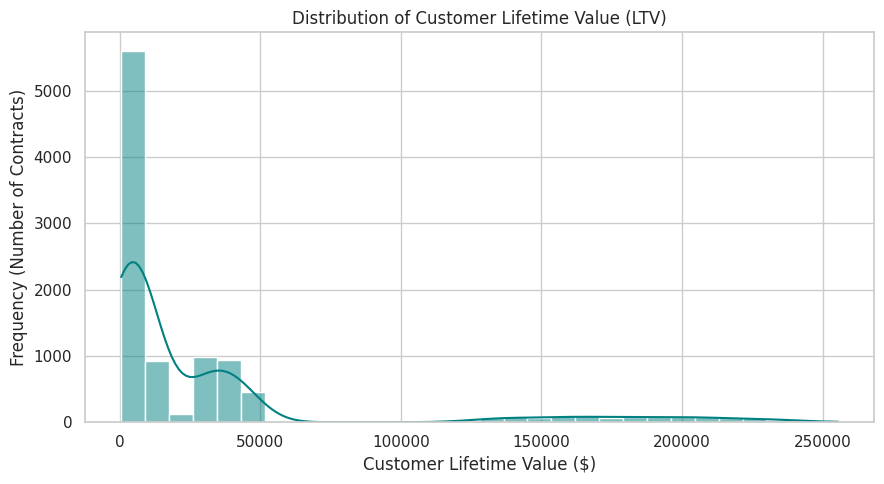

In [3]:
plt.figure(figsize=(9, 5))
# Histogram for Customer Lifetime Value
sns.histplot(df['Customer_Lifetime_Value'], bins=30, kde=True, color='teal')
plt.title('Distribution of Customer Lifetime Value (LTV)')
plt.xlabel('Customer Lifetime Value ($)')
plt.ylabel('Frequency (Number of Contracts)')
plt.tight_layout()
plt.show()

**Histogram Observation:** The LTV distribution is right-skewed. The vast majority of contracts generate returns under $40,000, but there is a distinct long tail of rare, highly lucrative Enterprise deals extending well past $250,000.

/tmp/ipykernel_58/3591801092.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Subscription_Tier', y='Customer_Lifetime_Value', data=df, palette='Set2')


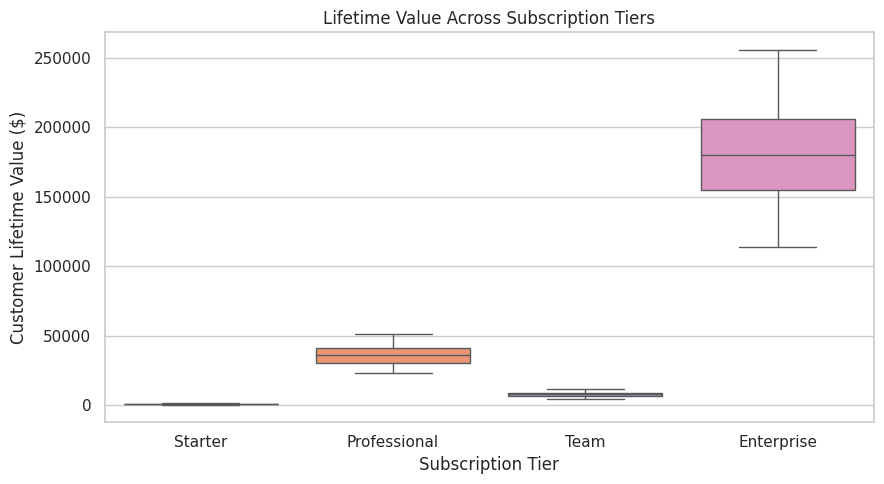

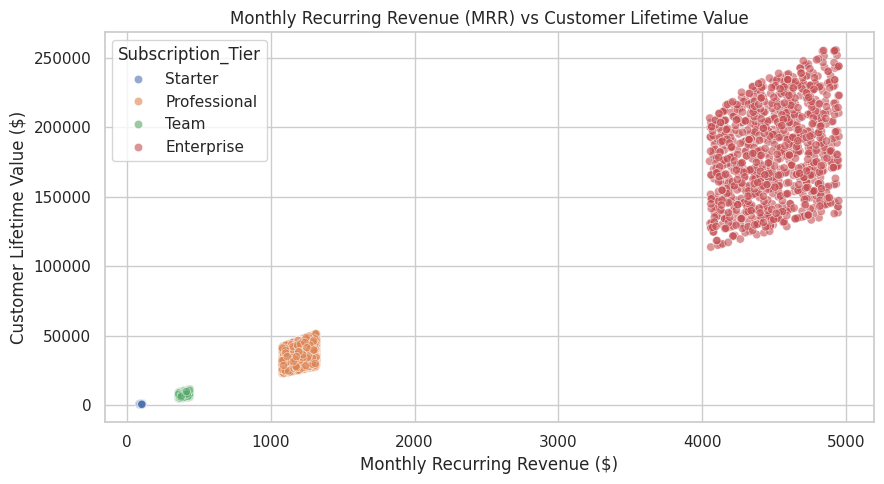

In [6]:
# Boxplot Diagram
plt.figure(figsize=(9, 5))
sns.boxplot(x='Subscription_Tier', y='Customer_Lifetime_Value', data=df, palette='Set2')
plt.title('Lifetime Value Across Subscription Tiers')
plt.xlabel('Subscription Tier')
plt.ylabel('Customer Lifetime Value ($)')
plt.tight_layout()
plt.show()

# Scatterplot Diagram
plt.figure(figsize=(9, 5))
sns.scatterplot(x='Monthly_Recurring_Rev', y='Customer_Lifetime_Value', hue='Subscription_Tier', data=df, alpha=0.6)
plt.title('Monthly Recurring Revenue (MRR) vs Customer Lifetime Value')
plt.xlabel('Monthly Recurring Revenue ($)')
plt.ylabel('Customer Lifetime Value ($)')
plt.tight_layout()
plt.show()

**Bivariate Observations:** 
* **Boxplot:** While the "Team" and "Starter" tiers have the highest sheer volume of contracts, "Enterprise" and "Professional" subscriptions generate exponentially higher median lifetime values and contain all major outlier deals.
* **Scatterplot:** There is a strict positive relationship between MRR and LTV. The data separates into clear visual clusters and trajectories based on the subscription tier's pricing and expected lifespan.

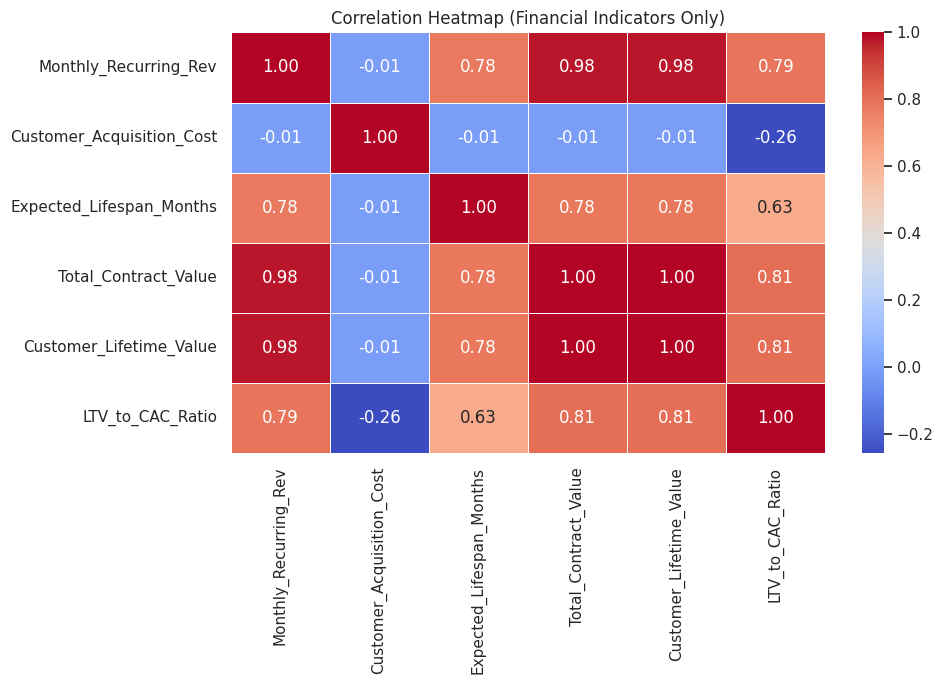

In [7]:
# Select only numeric columns to prevent data type errors
numeric_df = df.select_dtypes(include=['int64', 'float64']).drop(columns=['Contract_ID'])

# Correlation Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap (Financial Indicators Only)')
plt.tight_layout()
plt.show()

**Multivariate Observation:** The heatmap reveals that Customer Lifetime Value (LTV) correlates almost perfectly with Monthly Recurring Revenue (0.98). Surprisingly, LTV has virtually zero correlation (-0.01) with Customer Acquisition Cost (CAC), meaning spending more to acquire a client does not guarantee a higher overall return.

### Final Summary of Findings
1. **Data Quality:** The dataset is exceptionally robust with exactly zero missing values to clean across all 10,000 contract records.
2. **Product Profitability:** While the "Starter" and "Team" tiers drive high contract volume, "Professional" and "Enterprise" tiers act as the true drivers of massive financial spikes.
3. **Financial Correlations:** Simply spending a high budget to acquire customers (CAC) has no bearing on their total long-term value. Focus should instead be placed strictly on maximizing initial MRR and shifting clients into higher subscription tiers.